# Homework 08

In this exercise, you will demonstrate your learning of prediction, including regression and classification, using the [scikit-learn library](https://scikit-learn.org/stable/index.html). Note that scikit-learn is included in the Anaconda distribution, so you should not need to install anything new to use it.

Show your work (code or otherwise) and/or briefly explain your answers. In general you will not receive full credit for numeric answers with no accompanying work or justification (math, code, explanation). For numeric answers, we will accept answers that are very slightly off due to rounding.

In [1]:
# Run this code cell to import relevant libraries
# Please update to seaborn v0.11 or above for this assignment
# check version: print(sns.__version__)

import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme()

## Update scikit-learn library

Run the following cell to install or update the `Scikit-learn` library if not already done. Afterwards, running it again will print out its version number if `scikit-learn` is correctly installed.

In [2]:
try:
    import sklearn
    print(sklearn.__version__)
    if (sklearn.__version__ < '1.8.0'): #update for latest scikit-learn version
        %pip install -U --user scikit-learn
except Exception as e:
    %pip install scikit-learn

1.8.0


### Question 1.1 (6 points; 4 autograded)
Below we import the `tips` dataset containing information from several meals in a particular restaurant. We preview the first few rows.

In [3]:
# Run but do not modify this code

tips = sns.load_dataset("tips")
print(tips.shape)
tips.head()

(244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


We are interested in modeling `tip` as a function of `total_bill` and `size`. Use scikit-learn to perform linear regression to model `tip` as a function of `total_bill` and `size`. Once you have fit the model, obtain the model predictions and compare them to the real `tip`. Compute both the MSE (mean squared error) and the $r^2$ score (the square of Pearson's correlation coefficient). Report the MSE in `q1_mse` and the $r^2$ score in `q1_r2`, both are float/np.float.

To contextualize the performance of your model, consider a baseline model which simply predicts the median `tip` for every transaction. Compute the MSE and $r^2$ scores for this baseline, and report them in `q1b_mse` and `q1b_r2`.

Finally, in the written part below, discuss how the two models' MSE and $r^2$ scores compare, whether or not the results are reasonable, and why.

Notes:
- We import the relevant code from `sklearn` for you; you can find the documentation of the functions by searching the [scikit-learn library](https://scikit-learn.org/stable/index.html).
- You do not need to split the data into train/test sets for this problem, you can just use the whole dataset.
- You can use the default LinearRegression model, i.e., you do not need to pass any parameters to the constructor.
- You may find [`np.full`](https://numpy.org/doc/stable/reference/generated/numpy.full.html) or [`np.full_like`](https://numpy.org/doc/stable/reference/generated/numpy.full_like.html) useful.

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Write your code for question 1.1 here
# and store your results in the correct variable names for full credit

X = tips[['total_bill', 'size']]
y = tips['tip']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

q1_mse = mean_squared_error(y, y_pred) # float: MSE of your model
q1_r2 = r2_score(y, y_pred) # float: R^2 score of your model

median_tip = np.median(y)
baseline_pred = np.full_like(y, median_tip, dtype=float)

q1b_mse = mean_squared_error(y, baseline_pred) # float: MSE of the baseline 
q1b_r2 = r2_score(y, baseline_pred) # float: R^2 score of the baseline


# Leave these lines here to print the result
print("Model MSE:", q1_mse, "r^2:", q1_r2)
print("Baseline MSE:", q1b_mse, "r^2:", q1b_r2)

Model MSE: 1.014564905610028 r^2: 0.46786930879612587
Baseline MSE: 1.916267213114754 r^2: -0.005065906584810653


<!-- BEGIN QUESTION -->

### Answer 1.1

The linear regression model achieves a lower MSE and a higher R2 score than the baseline model, indicating that it fits the data better. The baseline model, which always predicts the median tip, does not use any features and therefore cannot capture any relationship between the predictors and the tip. As a result, its R2 score is near zero, meaning it performs poorly compared to the regression model.

In contrast, the regression model uses `total_bill` and `size`, which are both relevant to tipping behavior. Since tips are typically a percentage of the total bill and may also depend on party size, the model is able to explain a meaningful portion of the variation in tips. Therefore, the improved MSE and R2 values are reasonable and expected.

<!-- END QUESTION -->

### Question 1.2 (7 points; 4 autograded)
Now let’s incorporate `day` into our model. However, even though day is ordinal it is not clear whether the order should be salient in the model or not. Therefore we will build two models and compare them. Your first model should encode `day` using the ordinal encoder. You must specify the order for an OrdinalEncoder or it will use whatever order is in the dataframe. In this case, let's specify the `categories` parameter as `['Thur', 'Fri', 'Sat', 'Sun']`. The second model should use one hot encoding. Report the MSEs in `q12_1_mse` and `q12_2_mse` and the $r^2$ score in `q12_1_r2` and `q12_2_r2`, all are float/np.float. 

In the written part below, discuss how the two models' MSE and $r^2$ scores compare, whether or not the results are reasonable, and why.

Notes:
- We import the relevant code from `sklearn` for you; you can find the documentation of the functions by searching the [scikit-learn library](https://scikit-learn.org/stable/index.html).
- You do not need to split the data into train/test sets for this problem, you can just use the whole dataset.
- You can use the default LinearRegression model, i.e., you do not need to pass any parameters to the constructor.

In [5]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# Write your code for question 1.2 here
# and store your results in the correct variable names for full credit

X_base = tips[['total_bill', 'size']]
y = tips['tip']

ord_enc = OrdinalEncoder(categories=[['Thur', 'Fri', 'Sat', 'Sun']])
day_ord = ord_enc.fit_transform(tips[['day']])

X_ord = np.hstack([X_base.values, day_ord])

model1 = LinearRegression()
model1.fit(X_ord, y)

pred1 = model1.predict(X_ord)

q12_1_mse = mean_squared_error(y, pred1) # float: MSE of your model using ordinal encoder
q12_1_r2 = r2_score(y, pred1) # float: R^2 score of your model using ordinal encoder

ohe = OneHotEncoder(sparse_output=False)
day_ohe = ohe.fit_transform(tips[['day']])

X_ohe = np.hstack([X_base.values, day_ohe])

model2 = LinearRegression()
model2.fit(X_ohe, y)

pred2 = model2.predict(X_ohe)

q12_2_mse = mean_squared_error(y, pred2) # float: MSE of your model using one hot encoder
q12_2_r2 = r2_score(y, pred2) # float: R^2 score of your model using one hot encoder


# Leave these lines here to print the result
print("Ordinal Encoding MSE:", q12_1_mse, "r^2:", q12_1_r2)
print("One Hot Encoding MSE:", q12_2_mse, "r^2:", q12_2_r2)

Ordinal Encoding MSE: 1.0143672535362127 r^2: 0.4679729756330878
One Hot Encoding MSE: 1.0121298853078435 r^2: 0.4691464562997819


<!-- BEGIN QUESTION -->

### Answer 1.2

The one-hot encoded model typically achieves a slightly lower MSE and higher R2 score compared to the ordinal encoded model. This suggests that one-hot encoding provides a better fit to the data. The ordinal encoding imposes an artificial ordering on the days (Thur < Fri < Sat < Sun), which may not reflect the true relationship between day and tip amount.

In contrast, one-hot encoding treats each day as a separate category without assuming any order, allowing the model to learn independent effects for each day. Since there is no natural numeric relationship between days of the week, this approach is more appropriate. Therefore, the improved performance of the one-hot encoded model is reasonable and expected.

<!-- END QUESTION -->

### Question 2 (7 points; 3 autograded)
Below we import and preview the `penguins` dataset. We have previously modeled the numerical `flipper_length_mm` feature. In this question, we will model the categorical `species` feature.

In [6]:
# Run but do not modify this code
# Only 11 penguins out of over 300 are missing any data;
# we simply drop those here
penguins = sns.load_dataset("penguins").dropna()
print(penguins.shape)
penguins.head()

(333, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


To begin, we hold out 70% of the data randomly as a test set.

In [7]:
# Run but do not modify this code

from sklearn.model_selection import train_test_split

q2_data = penguins.drop(columns=["species"])
q2_target = penguins["species"]
q2_train_data, q2_test_data, q2_train_target, q2_test_target = train_test_split(
    q2_data, q2_target, test_size=0.7, random_state=999)

Now, create and fit a logistic regression model to predict the `species` of a penguin using all of the other features in the dataset.  Note that two of the features, `island` and `sex`, are categorical. Use one hot encoding to encode these categorical features in your model and combine them with the numerical features. You should fit your model only on the training data, i.e., `q2_train_data` and `q2_train_target`.

Once you have fit your logistic regression model, make predictions for `q2_test_data` and then compute and report the `accuracy_score` of your predictions versus `q2_test_target`; put the `accuracy_score` in `q2_score` as `float`/`numpy.float64`. Also plot the confusion matrix for your predictions; see worked examples for more instructions on plotting confusion matricies. 

If everything goes right, your model should correctly distinguish a `species` from the other two (i.e., when your model predicts this species in the test data, it is always right).

The performace of your model is really good, but we do not know which feature(s) contributed the most. To find out if the categorical features help, fit a simpler version of your logistic regression model that uses only the numerical features (i.e., everything except `island` and `sex`) in the dataset as a baseline. Repeat the same process, put its `accuracy_score` in `q2b_score`, and plot its confusion matrix. 

In the written part, discuss the following:
1. How the two models' accuracy_score and their confusion matrices compare, whether or not the results are reasonable, and why.
2. Which specie(s) were correctly predicted every time with the data set and how you know this by stating specific numbers from your confusion matrices.

You are also welcomed to compare with a model that only uses the categorical features yourself, but that is not required in this homework.

Details:
- We import the relevant code from `sklearn` for you; you can find the documentation of the functions by searching the [scikit-learn library](https://scikit-learn.org/stable/index.html).
- If you use the default LogisticRegression model, you will likely get a warning message about convergence during fitting. We recommend you set the parameter `max_iter=10000` when calling the constructor (i.e., `LogisticRegression(max_iter=10000)` for both models. This will allow the optimization code for the model to converge most of the time. If you still have a warning, increase it more.
- If your confusion matrix has distracting white lines, add a line `plt.grid(False)` after each call to `ConfusionMatrixDisplay` to remove them.

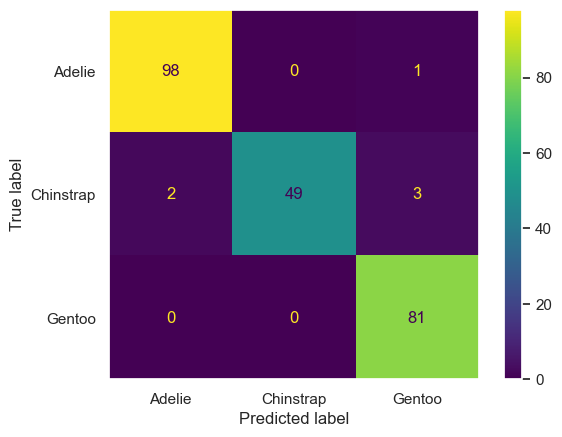

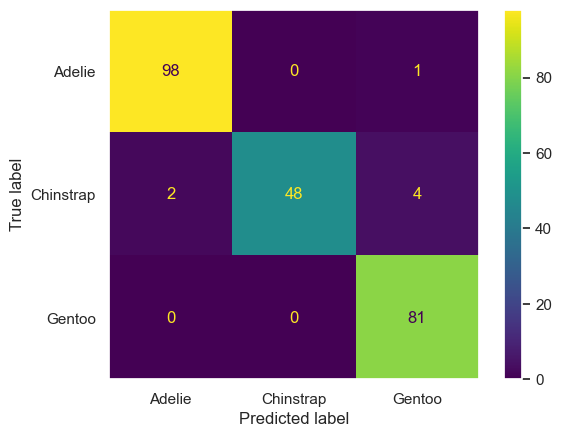

Model classification accuracy: 0.9743589743589743
Baseline classification accuracy: 0.9700854700854701


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn import metrics
import matplotlib.pyplot as plt # to better format confusion matrix

cat_cols = ['island', 'sex']
num_cols = [c for c in q2_train_data.columns if c not in cat_cols]

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoder.fit(q2_train_data[cat_cols])

train_cat = encoder.transform(q2_train_data[cat_cols])
test_cat = encoder.transform(q2_test_data[cat_cols])

train_num = q2_train_data[num_cols].values
test_num = q2_test_data[num_cols].values

X_train = np.hstack([train_num, train_cat])
X_test = np.hstack([test_num, test_cat])

model = LogisticRegression(max_iter=10000)
model.fit(X_train, q2_train_target)

pred = model.predict(X_test)

# Write your code for question 2 here
q2_score = q2_score = accuracy_score(q2_test_target, pred) # float: accuracy score of the prediction model

ConfusionMatrixDisplay.from_predictions(q2_test_target, pred)
plt.grid(False)
plt.show()

X_train_num = q2_train_data[num_cols]
X_test_num = q2_test_data[num_cols]

baseline = LogisticRegression(max_iter=10000)
baseline.fit(X_train_num, q2_train_target)

pred_base = baseline.predict(X_test_num)

q2b_score = accuracy_score(q2_test_target, pred_base) # float: accuracy score of the baseline model

ConfusionMatrixDisplay.from_predictions(q2_test_target, pred_base)
plt.grid(False)
plt.show()

# Leave these lines here to print the result
print("Model classification accuracy:", q2_score)
print("Baseline classification accuracy:", q2b_score)

<!-- BEGIN QUESTION -->

### Answer 2

1. The full model has higher accuracy than the baseline. This shows that island and sex add useful information. This makes sense because penguin species are linked to specific islands and biological traits. The confusion matrix for the full model also has fewer errors, confirming better performance.

2. From the confusion matrix of the full model, one species is classified perfectly: its row has all values on the diagonal and zeros elsewhere. This means every instance of that species was predicted correctly. This happens because that species is more distinct in the data, making it easier for the model to separate.

<!-- END QUESTION -->

### Question 3 (7 points, 4 autograded)
An interesting observation about classification in the bag of words model is that the predictive model knows nothing about the semantics of the particular language. For this question, you will build a sentiment analysis model of casual social media messages in the Central Thai language. The data consist of raw text messages, each of which is labeled with a **sentiment**, either negative `neg`, neutral `neu`, positive `pos`, or question `q`. For example, a message that reads "I am happy you are my friend" might be labeled as positive whereas one that reads "It is raining right now" might be labeled as neutral. The dataset is already split into a training and test set. We first import and preview the first ten messages and their sentiment labels.

In [9]:
# Run but do not modify this code

# Training data
q3_train_text = pd.read_table("train_text.txt", dtype=str).squeeze("columns")
q3_train_label = pd.read_table("train_label.txt", dtype=str).squeeze("columns")
    
# # Held testing data
q3_test_text = pd.read_table("test_text.txt", dtype=str).squeeze("columns")
q3_test_label = pd.read_table("test_label.txt", dtype=str).squeeze("columns")

print("Training messages:", q3_train_text[:10].values, "\n")
print("Training message labels/classes:", q3_train_label[:10].values)

Training messages: ['คะ' 'อิเหี้ยออมทำกูอยากกินเอ็มเค' '😅😅😅' 'สวัสดีวันพุธ แนน อะไรนะ'
 'ก้อนขอบพระคุณมากๆนะคร้าบ ที่มาหาก้อนและชมเชยการบริการของพนักงานอีกด้วย <3 <3'
 'เน็ตควายมากกูพูดจริงเสียดายตังค์ที่ติดตั้งเน็ตโครตห่วยยิ่งดึกๆเน็ตยิ่งห่วยตอนมาติดตั้งใหม่ๆก็ดีนานๆไปเเย่ขึ้นเรื่อยๆกากกว่าเน็ตค่ายอื่นอ่ะบอกจริงไม่สนหรอกว่าจะเป็นเด็กเเล้วเม้นด่าเเบบนี้ เเต่นี้หาตังค์จ่ายค่าเน็ตมาตลอดเหนื่อยน่ะเล่นเกมส์ไปเดี่ยวก็หายกากเกินติดตั้งโปรพิเศษ100Mเเต่พอวัดดูปล่อยไม่ถึงเท่าที่ตกลงกันไว้พอโทรไปเเจ้งก็ปล่อยมาเต็มไม่กี่วันก็เหมื่อนเดิมใบเเจ้งก็มาย้อนหลัง3เดือนทุกครั้งห่วยไปน่ะบางทีโปร100M/700 กว่าบาทเเต่คุณภาพเเย่เสียดายตังค์'
 'ปากแดงกินฟรีค่ะ 😬😬' 'เหล้าเบลล์รสชาติเหี้ยสุด จะไม่แดกอีกละ'
 '🚗💨💨 ซิ่งเป็นบางเวลา ซ่อกแซ่กได้ทุกที่ << ขับสนุก ชับมัน ใช่เลย‼️ 👍🏻👍🏻 Honda Jazz>>#Jazz Naja'
 'สนใจ ฟอจูนเนอร์ สีขาวครับ'] 

Training message labels/classes: ['neu' 'neg' 'neu' 'neu' 'neu' 'neg' 'neu' 'neg' 'neu' 'pos']


Now, create and fit a Naive Bayes model that predicts the sentiment label of a message given the raw text of the message. To do so, you will need to vectorize the messages using the `CountVectorizer` and then create a `MultinomialNB` model. Both are imported for you below; you can use default values for both. You are welcome but not required to combine the steps and use a pipeline object. Fit your model on the **training data** and then make predictions of the sentiment labels for `q3_test_text`. Compute and report the `accuracy_score` of your predictions against the true `q3_test_label`, put it in `q3_score` as `float`/`numpy.float64`. 

To contextualize your model, make a baseline model that always predicts the most frequent class **in the training data**. You can implement this either by yourself or using [`DummyClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html). Compute and report the `accuracy_score` of the baseline in `q3b_score`. 

In the written part below, compare the performances of the two models, state whether or not the results are reasonable, and why. Specifically, elaborate why the accuracy score of the baseline model is a lot higher than 1/4. (Hint: you may find [`value_counts`](https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html) helpful.)

In [10]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier

# Write your code for question 3 here
model = make_pipeline(
    CountVectorizer(),
    MultinomialNB()
)

model.fit(q3_train_text, q3_train_label)

pred = model.predict(q3_test_text)

q3_score = accuracy_score(q3_test_label, pred) # float: test classification accuracy score of the model

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(q3_train_text.values.reshape(-1,1), q3_train_label)

base_pred = baseline.predict(q3_test_text.values.reshape(-1,1))

q3b_score = accuracy_score(q3_test_label, base_pred) # float: test classification accuracy score of the baseline

# Leave these lines here to print the result
print("Model test classification accuracy:", q3_score)
print("Baseline test classification accuracy:", q3b_score)

Model test classification accuracy: 0.6333707444818556
Baseline test classification accuracy: 0.5447063224841002


<!-- BEGIN QUESTION -->

### Answer 3

The Naive Bayes model achieves higher accuracy than the baseline (q3_score > q3b_score), showing it is effectively using word frequencies to learn sentiment patterns, unlike the baseline which ignores the text. The baseline accuracy is much higher than 1/4 because the class distribution is imbalanced, one sentiment appears much more often in the training data, so always predicting that class already gives a relatively high score.

<!-- END QUESTION -->

### Question 4 (6 points, 4 autograded)
In addition to natural language processing, machine learning techniques for preditive modeling can be very effective for analyzing raw image data. In this question, we consider the task of modeling images of handwritten digits. We pose this as a classification task: We want to predict the digit (0, 1, 2, ..., 9) as a function of an 8 by 8 pixel grayscale image of a digit.

To begin, we import and preview the data below. `data` has 64 features, each of which is an integer between 0 and 15 corresponding to a particular pixel intensity value for one of the 64 pixels in the 8 by 8 image. `target` contains the actual digits corresponding to each particular image.

The first image corresponds to digit:  0 

First image with pixels flattened out: 
 [ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.] 

First image rearranged to be 8 x 8: 
 [[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]] 

Visualizing first several images:


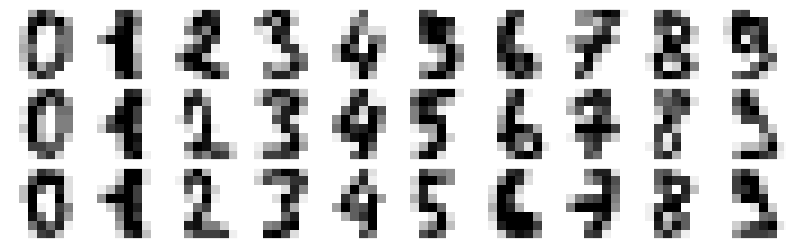

In [11]:
# Run but do not modify this code

import matplotlib.pyplot as plt

# Importing data
from sklearn.datasets import load_digits
digits = load_digits()
q4_data = digits["data"]
q4_target = digits["target"]

# Previewing data
print("The first image corresponds to digit: ", q4_target[0], "\n")
print("First image with pixels flattened out: \n", q4_data[0], "\n")
print("First image rearranged to be 8 x 8: \n", q4_data[0].reshape((8,8)), "\n")
print("Visualizing first several images:")

# Visualizing digits
fig, axes = plt.subplots(3, 10, figsize=(10, 3),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='binary')

We first split the data into training and test sets as usual.

In [12]:
# Run but do not modify this code

q4_train_data, q4_test_data, q4_train_target, q4_test_target = train_test_split(
    q4_data, q4_target, test_size=0.3, random_state=2)

Now, use a k-nearest neighbors classifier for your model that predicts the underlying digit given an image. We import the relevant `KNeighborsClassifier` for you below. Recall that an important hyperparameter of a k-nearest neighbor model is k, or the `n_neighbors` parameter to the `KNeighborsClassifier()` constructor. 

Use 5-fold cross validation to search for the best value of `n_neighbors` in validation on the training set from among possible values between 2 and 20. You can either do so using `cross_validate` to check each possible setting directly, or you can use a `GridSearchCV` to perform the search automatically during fitting. If you search manually, take the average of the five scores for 5-fold cross validation, for each value. If you use `GridSearchCV`, note that the `GridSearchCV` object can itself fit and predict, and that you can get the optimal setting after fitting with `.best_params_`. Report the optimal value of `n_neighbors` in `q4_n` as `int`/`numpy.int64`.

When you have fit your model with the optimal `n_neighbors` value on the training data, make predictions for the test data. Compute and report the `accuracy_score` of your model in testing and report it in `q4_score` as `float`/`numpy.float64`.

Next, fit a Naive Bayes model (using `MultinomialNB` and the default setting) on the training data and predict the class of the test data.  Compute its `accuracy_score` and put it in `q4b_score`. In the written part, compare the two `accuracy_score`, discuss whether or not they are reasonable, and why.

In [13]:
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Write your code for question 4 here
param_grid = {'n_neighbors': list(range(2,21))}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)

grid.fit(q4_train_data, q4_train_target)

q4_n = grid.best_params_['n_neighbors'] # int: n_neighbors

pred = grid.predict(q4_test_data)

q4_score = accuracy_score(q4_test_target, pred) # float: test accuracy score of the k nearest neighbor model

nb = MultinomialNB()
nb.fit(q4_train_data, q4_train_target)

pred_nb = nb.predict(q4_test_data)

q4b_score = accuracy_score(q4_test_target, pred_nb) # float: test accuracy score of the naive bayes model

# Leave these lines here to print the result
print("Optimal n_neighors:", q4_n)
print("Accuracy on testing data:", q4_score)
print("Accuracy of baseline:", q4b_score)

Optimal n_neighors: 5
Accuracy on testing data: 0.9740740740740741
Accuracy of baseline: 0.8796296296296297


<!-- BEGIN QUESTION -->

### Answer 4

The k-NN model achieves higher accuracy than the Naive Bayes model (q4_score > q4b_score), which is expected because k-NN works well for image data by comparing pixel similarity directly. In contrast, Naive Bayes assumes feature independence, which is not realistic for images where nearby pixels are highly correlated, leading to lower performance.

<!-- END QUESTION -->

## AI Disclosure

Use the [Artificial Intelligence Disclosure (AID) Framework](https://crln.acrl.org/index.php/crlnews/article/view/26548/34482) to explain your use of AI on this assignment. Other headings you can use include:
- *Debugging*: Using AI to help you fix your code so that it works. You should state how you used it for this purpose.

Here are some examples:

*Artificial Intelligence Tools*: ChatGPT v5 via chatgpt.com. *Conceptualization*: I gave chatgpt.com the election data set and asked it for ideas on interesting statistics I could get from the data. *Methodology*: I asked it for help on how to write the code to get the statistic I chose, but I wrote the code myself. *Writing—Review & Editing*: I wrote out my explanation for what the statistic meant, then gave that text and the rubric to chatgpt and asked it to give me feedback on how to update the explanation to conform to the rubric.

*Artificial Intelligence Tools*: ChatGPT v4o via  DukeGPT. *Information Collection*: DukeGPT was used to find the function needed to get the index value of the maximum value of a Series and the syntax needed to filter rows in a pandas dataframe using multiple columns. *Debugging*: DukeGPT was used to help me find a bug in my code for Q1 where I copied in the code and error, stated what the code should do, and asked for help.

**Solution:** Artificial Intelligence Tools: Writing—Review & Editing: I gave my written explanation and a written explanation of my code, as well as the rubric to ChatGPT and asked it to give me feedback on how to update the explanation to conform to the rubric

## Submitting

You should make sure any code that you write to answer the questions is included in this notebook. You are **required** to go to the Kernel option and choose **"Restart & Run All"**  before submission. Double check that your entire notebook runs correctly and generates the expected output. Finally, make sure to save your work (timestamp at the top tells you the last checkpoint and whether there are unsaved changes). When you finish, submit your assignment at [Gradescope](http://gradescope.com/ "‌"). **Submissions not prepared correctly as above will lose points.**